# Customer Segmentation Analysis
---

### 1. Project Objective
---
The objective of this project is to analyze an e-commerce company's customer purchasing behaviour and segment customers into distinct groups using **RFM (Recency, Frequency, Monetary) analysis and K-Means clustering**.

The analysis focuses on:

- Customer purchasing behaviour
- Recency, Frequency, and Monetary value
- Average purchase value and purchase frequency
- Customer lifetime value
- Customer segmentation using K-Means clustering
- Identification of the optimal number of customer segments using the Elbow Method
- Comparison of behavioural characteristics across customer segments
- Visualization of customer clusters
- Customer distribution across different segments
- Marketing strategies for each customer segment

The goal is to identify **data-driven customer segments** that can help the e-commerce company understand its customers better and develop targeted marketing strategies to improve **customer retention, engagement, and revenue**.


---
### 2.Import libraries
---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

---
### 3.Loading Dataset
---

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

---
### 4.Inspect the dataset
---

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    236000 non-null  object 
 1   StockCode    236000 non-null  object 
 2   Description  235108 non-null  object 
 3   Quantity     236000 non-null  float64
 4   InvoiceDate  236000 non-null  object 
 5   UnitPrice    236000 non-null  float64
 6   CustomerID   169475 non-null  float64
 7   Country      236000 non-null  object 
dtypes: float64(3), object(5)
memory usage: 33.1+ MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,236000.000000,236000.000000,169475.000000
mean,9.276148,5.104420,15274.225148
std,224.930231,120.035541,1726.372604
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13824.000000
50%,3.000000,2.100000,15143.000000
75%,10.000000,4.210000,16814.000000
max,74215.000000,38970.000000,18287.000000


---
### 5.Check missing values
---

In [9]:
df.isnull().sum()

InvoiceNo      305909
StockCode      305909
Description    306801
Quantity       305909
InvoiceDate    305909
UnitPrice      305909
CustomerID     372434
Country        305909
dtype: int64

In [10]:
missing_percentage = df.isnull().sum() / len(df) * 100

missing_percentage.sort_values(ascending=False)

CustomerID     68.726299
Description    56.614856
StockCode      56.450253
InvoiceNo      56.450253
Quantity       56.450253
InvoiceDate    56.450253
UnitPrice      56.450253
Country        56.450253
dtype: float64

In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
df.shape

(169475, 8)

Missing CustomerID values were removed because customer-level identification is necessary for RFM analysis and customer segmentation.

---
### 6.Check duplicates
---

In [13]:
df.duplicated().sum()

np.int64(1917)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(167558, 8)

---
### 7.Check cancelled transactions
---

In [16]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(4053)

In [17]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

---
### 8.Check Quantity
---

In [18]:
df['Quantity'].describe()

count    163505.000000
mean         13.469117
std         189.349404
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       74215.000000
Name: Quantity, dtype: float64

In [19]:
df = df[df['Quantity'] > 0]

---
### 9.Check UnitPrice
---

In [20]:
df['UnitPrice'].describe()

count    163505.000000
mean          3.298760
std          24.514724
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [21]:
df = df[df['UnitPrice'] > 0]

---
### 10.Convert InvoiceDate
---

In [22]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [23]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

---
### 11.Data Cleaning
---

In [24]:
df = df.dropna(subset=['CustomerID'])

df = df.drop_duplicates()

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [25]:
print("Rows after cleaning:", df.shape[0])
print("Columns:", df.shape[1])

Rows after cleaning: 163492
Columns: 8


#### Data Cleaning Summary

The dataset was cleaned by:

- Removing transactions with missing CustomerID
- Removing duplicate records
- Removing cancelled invoices
- Removing transactions with non-positive quantities
- Removing transactions with non-positive unit prices
- Converting InvoiceDate to datetime format

---
### 12.Create Total Purchase Amount
---

In [26]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
### 13.Descriptive statistics
---

In [28]:
customer_summary = df.groupby('CustomerID').agg(
    TotalSpent=('TotalAmount', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalItems=('Quantity', 'sum')
).reset_index()

In [29]:
customer_summary.head()

,CustomerID,TotalSpent,TotalOrders,TotalItems
0,12346.0,77183.60,1,74215.0
1,12347.0,2205.95,4,1313.0
2,12348.0,1487.24,3,2124.0
3,12350.0,334.40,1,197.0
4,12352.0,1561.81,5,254.0


---
### 14.Average purchase value
---

In [30]:
customer_summary['AveragePurchaseValue'] = (
    customer_summary['TotalSpent'] /
    customer_summary['TotalOrders']
)

In [31]:
customer_summary['AveragePurchaseValue'].describe()

count     2907.000000
mean       406.449621
std       1527.331726
min          2.900000
25%        170.322222
50%        288.500000
75%        415.484000
max      77183.600000
Name: AveragePurchaseValue, dtype: float64

---
### 15.Purchase frequency
---

In [32]:
customer_summary['TotalOrders'].describe()

count    2907.000000
mean        2.897145
std         4.399456
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        97.000000
Name: TotalOrders, dtype: float64

---
### 16.Customer Lifetime Value
---

In [33]:
customer_summary['TotalSpent']

0       77183.60
1        2205.95
2        1487.24
3         334.40
4        1561.81
          ...   
2902       51.00
2903      180.60
2904       80.82
2905      619.24
2906      765.28
Name: TotalSpent, Length: 2907, dtype: float64

In [34]:
customer_summary['TotalSpent'].describe()

count      2907.000000
mean       1314.784672
std        4730.425960
min           2.900000
25%         246.570000
50%         486.990000
75%        1106.895000
max      121973.650000
Name: TotalSpent, dtype: float64

---
### 17.Create RFM
---

In [35]:
df['InvoiceDate'].max()

Timestamp('2011-06-22 10:11:00')

---
### 18.Calculate RFM
---

In [36]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-06-23 10:11:00')

In [37]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,156,1,77183.60
1,12347.0,13,4,2205.95
2,12348.0,78,3,1487.24
3,12350.0,140,1,334.40
4,12352.0,92,5,1561.81


---
### 19.Explore RFM distributions
---

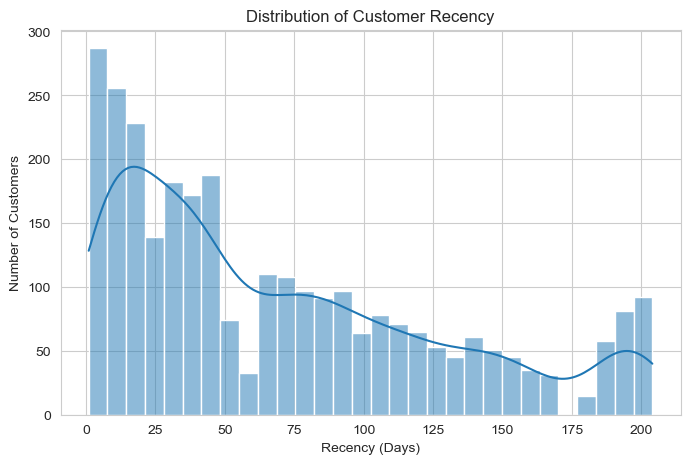

In [38]:
# Recency

plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.show()

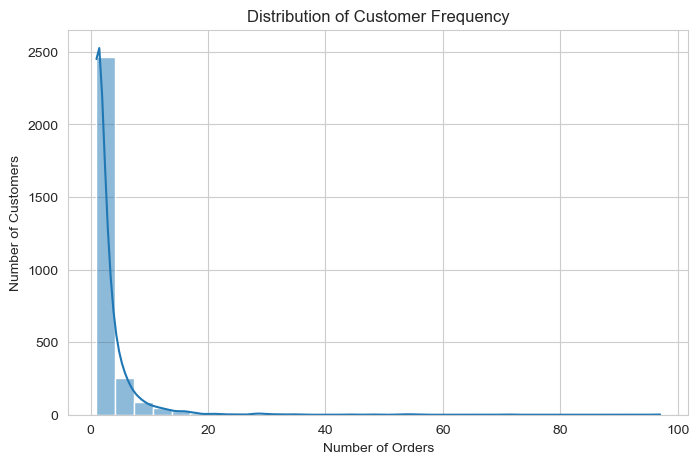

In [39]:
# Frequency

plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Distribution of Customer Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

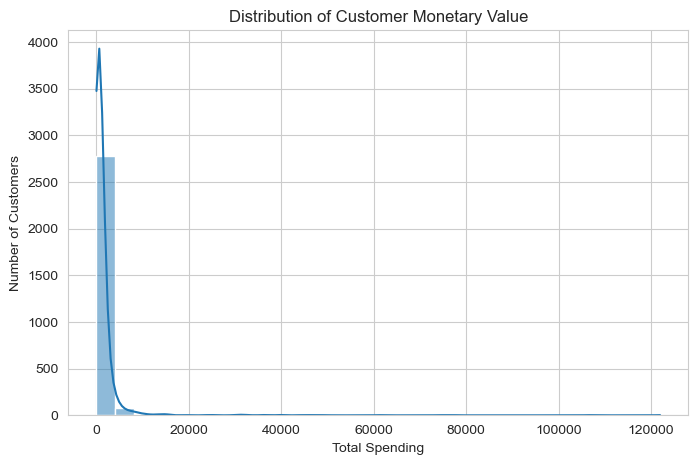

In [40]:
# Monetary

plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

---
### 20.Log transform RFM
---

In [41]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

In [42]:
rfm_log = np.log1p(rfm_log)

In [43]:
rfm_log.head()

,Recency,Frequency,Monetary
0,5.056246,0.693147,11.253955
1,2.639057,1.609438,7.699367
2,4.369448,1.386294,7.305349
3,4.948760,0.693147,5.815324
4,4.532599,1.791759,7.354241


---
### 21.StandardScaler
---

In [44]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [45]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

In [46]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.139405,-0.789247,4.275585
1,-1.019726,0.833284,1.215773
2,0.525929,0.438150,0.876601
3,1.043394,-0.789247,-0.406023
4,0.671663,1.156131,0.918687


---
### 22.Find the optimal K
---

In [47]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from sklearn.cluster import KMeans


In [48]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

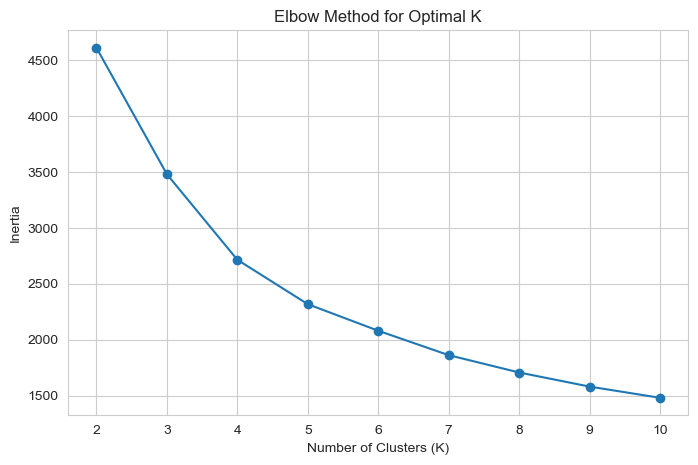

In [49]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

---
### 23.Train the final K-Means model
---

In [50]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [51]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,156,1,77183.60,0
1,12347.0,13,4,2205.95,3
2,12348.0,78,3,1487.24,0
3,12350.0,140,1,334.40,2
4,12352.0,92,5,1561.81,0


---
### 24.Profile the clusters
---

In [52]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean')
).round(2)

cluster_profile

,Customers,AvgRecency,AvgFrequency,AvgMonetary
Cluster,,,,
0,826,58.41,2.88,1291.85
1,445,12.20,1.78,499.10
2,1244,114.28,1.13,280.26
3,392,14.67,9.81,5572.12


In [53]:
cluster_profile['CustomerPercentage'] = (
    cluster_profile['Customers'] /
    cluster_profile['Customers'].sum() * 100
).round(2)

In [54]:
cluster_profile

,Customers,AvgRecency,AvgFrequency,AvgMonetary,CustomerPercentage
Cluster,,,,,
0,826,58.41,2.88,1291.85,28.41
1,445,12.20,1.78,499.10,15.31
2,1244,114.28,1.13,280.26,42.79
3,392,14.67,9.81,5572.12,13.48


---
### 25.Visualize clusters
---

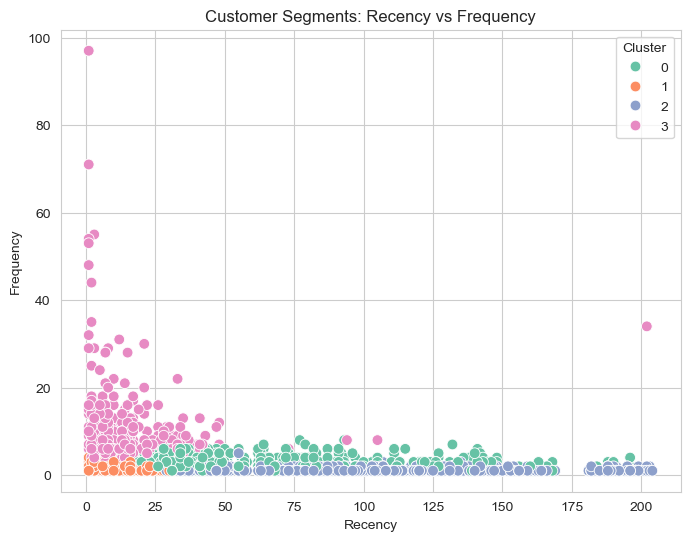

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

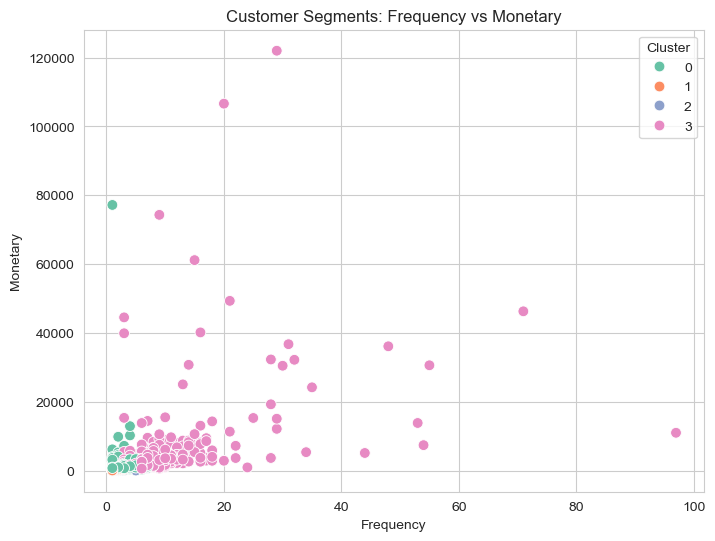

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

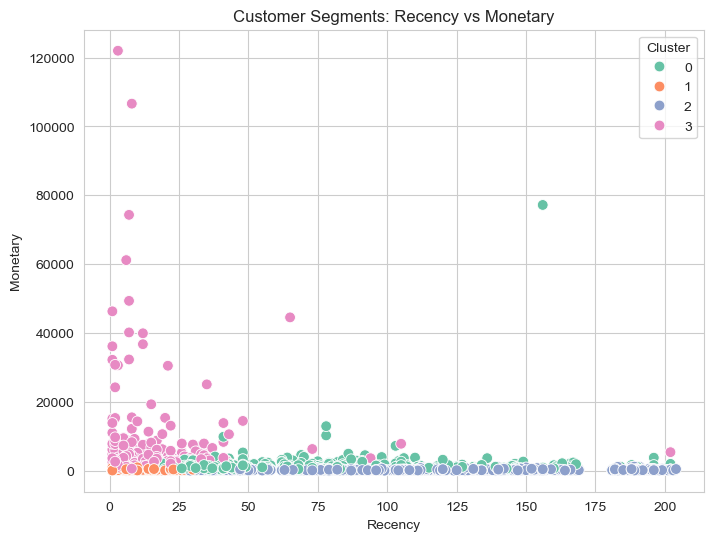

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')

plt.show()

---
### 26.Bar chart: customers per cluster
---

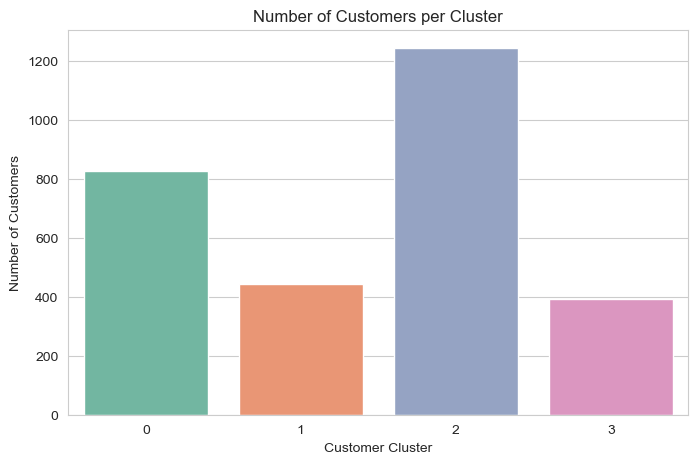

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Cluster',
    hue='Cluster',
    palette='Set2',
    legend=False
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

plt.show()

---
### 27.Cluster Profile
---

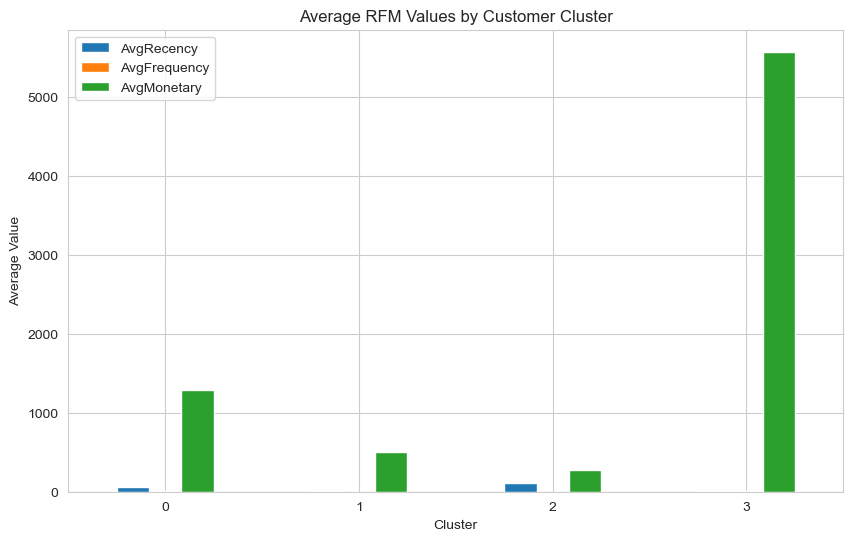

In [59]:
profile_plot = cluster_profile[
    ['AvgRecency', 'AvgFrequency', 'AvgMonetary']
]

profile_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average RFM Values by Customer Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')

plt.xticks(rotation=0)
plt.legend()

plt.show()

In [60]:
cluster_names = {
    0: 'High-Value Loyal Customers',
    1: 'At-Risk Customers',
    2: 'Regular Customers',
    3: 'New/Recent Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

---
### 15. Marketing Recommendations

---

Based on the RFM characteristics of each customer segment, targeted marketing strategies can be developed to improve customer engagement, retention, and revenue.

- **High-Value Customers (Cluster 0):** These customers have relatively recent purchases, good purchase frequency, and high monetary value. They should be targeted with VIP rewards, exclusive offers, early access to new products, and personalized recommendations to maintain their loyalty.

- **Recent Low-Engagement Customers (Cluster 1):** These customers have purchased very recently but show low purchase frequency and moderate spending. Welcome offers, personalized recommendations, and incentives for a second purchase can help convert them into regular customers.

- **At-Risk / Inactive Customers (Cluster 2):** These customers have the highest average recency, the lowest purchase frequency, and low monetary value. They represent the largest customer segment and should be targeted with win-back campaigns, personalized discounts, re-engagement emails, and special offers to encourage them to return.

- **Highly Valuable Loyal Customers (Cluster 3):** These customers have very high purchase frequency and the highest monetary value, making them the most valuable customer segment. They should be targeted with premium loyalty programs, exclusive rewards, personalized offers, cross-selling, and upselling opportunities to strengthen long-term relationships.

These targeted strategies can help the company improve customer retention, increase repeat purchases, and maximize customer lifetime value.